# Proyecto Final Minería
## Fase 1 - Exploración profunda + formulación

Gerardo Andre Fernandez Cruz 23763 

José Gerardo Ruiz García 23719 

Melisa Dayana Mendizabal Meléndez 23778 

Renato Manuel Rojas Roldan 23813 


Este proyecto tiene como objetivo analizar patrones de uso de Internet en distintos países latinoamericanos, considerando variables como el año de medición, el grupo etario y el porcentaje de adopción de Internet. Para ello, se aplican técnicas de clustering o agrupamiento no supervisado, con el fin de identificar comportamientos similares entre observaciones y descubrir posibles tendencias ocultas en los datos.

Como parte del análisis, se evalúan distintos modelos de clustering, incluyendo K-Means, Gaussian Mixture, OPTICS y Agglomerative Clustering, comparando su desempeño mediante métricas como el Silhouette Score y herramientas de visualización como PCA y dendrogramas. Posteriormente, los grupos encontrados se utilizan para realizar predicciones temporales utilizando Prophet, permitiendo estimar la evolución futura del uso de Internet en los diferentes clusters identificados.

---

### IMPORTACIÓN DE LIBRERÍAS
NOTA:
Prophet debe instalarse previamente con:
pip install prophet



In [123]:
import pandas as pd
from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.cluster import OPTICS 
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

import logging
logging.getLogger('cmdstanpy').disabled = True


### Carga y preparación de datos
Leer archivo CSV transformado
Eliminar la columna textual del grupo etario, ya que ya existe una versión ordinal numérica

In [124]:

# Leer datos
df = pd.read_csv("datos_transformados.csv")
X_GENERAL = df.drop(columns=["Grupos etarios Uso Internet"]) 

### FUNCIÓN PARA GENERAR PREDICCIONES POR CLUSTER
Esta función se encargar de agrupar datos por cluster, luego calcula el promedio de uso de internet por año, para luego entrenar un modelo Prophet que predice años futuros con Graficas datos reales y predicciones.

In [125]:
def prophet_por_clusters(df, cluster_col, forecast_years=5):
    plt.figure(figsize=(14,8))
    clusters = sorted(df[cluster_col].unique())
    for c in clusters:
        temp = (
            df[df[cluster_col] == c]
            .groupby("Años__ESTANDAR")["value"]
            .mean()
            .reset_index()
        )
        temp = temp.rename(columns={
            "Años__ESTANDAR": "ds",
            "value": "y"
        })
        temp["ds"] = pd.to_datetime(
            temp["ds"],
            format="%Y"
        )
        model = Prophet(
            yearly_seasonality=False,
            weekly_seasonality=False,
            daily_seasonality=False
        )
        model.fit(temp)

        future = model.make_future_dataframe(
            periods=forecast_years,
            freq='YE'
        )
        forecast = model.predict(future)
        #prediccion
        plt.plot(
            forecast["ds"],
            forecast["yhat"],
            label=f"Cluster {c}"
        )
        #reales
        plt.scatter(
            temp["ds"],
            temp["y"],
            s=40
        )
        #graficar
    plt.title(f"Evolución temporal por clusters ({cluster_col})")
    plt.xlabel("Año")
    plt.ylabel("Uso promedio de Internet")
    plt.legend()
    plt.grid(True)
    plt.show()


## CLUSTERING CON GAUSSIAN MIXTURE MODEL


In [126]:
gaussian_scaler = StandardScaler()
X_escalado_Gauss = gaussian_scaler.fit_transform(X_GENERAL)

gmm = GaussianMixture(
    n_components=14,                   #con prueba y error, se encontró que el mejor silhouette score daba era con 14, pero se puede analizar en la siguiente semana si existe otro (o cambiando el covariancetype u otro parámetro)
    covariance_type='full',
    random_state=42
)
gmm.fit(X_escalado_Gauss)

clusters_gauss = gmm.predict(X_escalado_Gauss)
df["cluster_gmm"] = clusters_gauss

### EVALUACIÓN DEL MODELO GMM
Mostrar algunas columnas importantes

In [127]:

print(df[[
    "Años__ESTANDAR",
    "value",
    "grupo_etario_ord",
    "cluster_gmm"
]].head())


score = silhouette_score(X_escalado_Gauss, clusters_gauss)
print("Silhouette Score:", score)


   Años__ESTANDAR  value  grupo_etario_ord  cluster_gmm
0            2016     76                 0           11
1            2017     76                 0           11
2            2018     79                 0           11
3            2019     79                 0           11
4            2020     88                 0           11
Silhouette Score: 0.6377766716735552


### Visualización de clusters con PCA

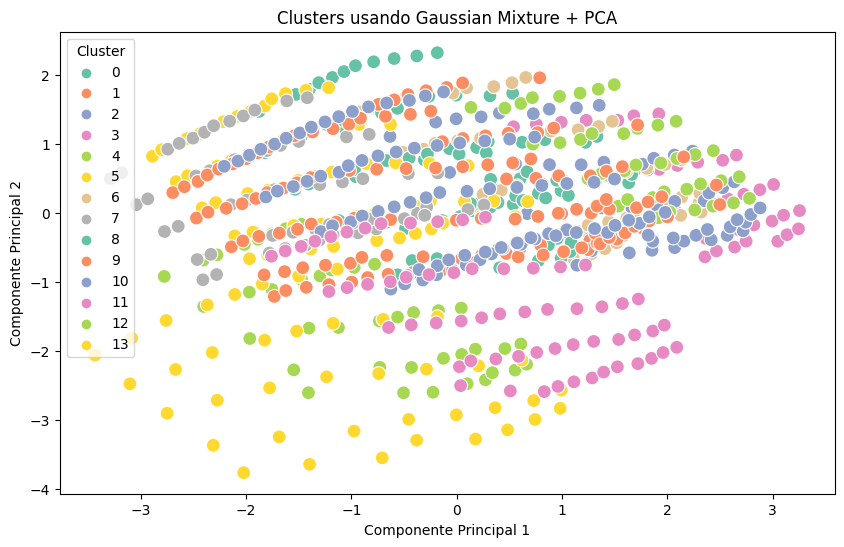

In [128]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado_Gauss)
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_gauss,
    palette='Set2',
    s=100
)
plt.title("Clusters usando Gaussian Mixture + PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Cluster")
plt.show()

### Predicción temporal usando clusters GMM

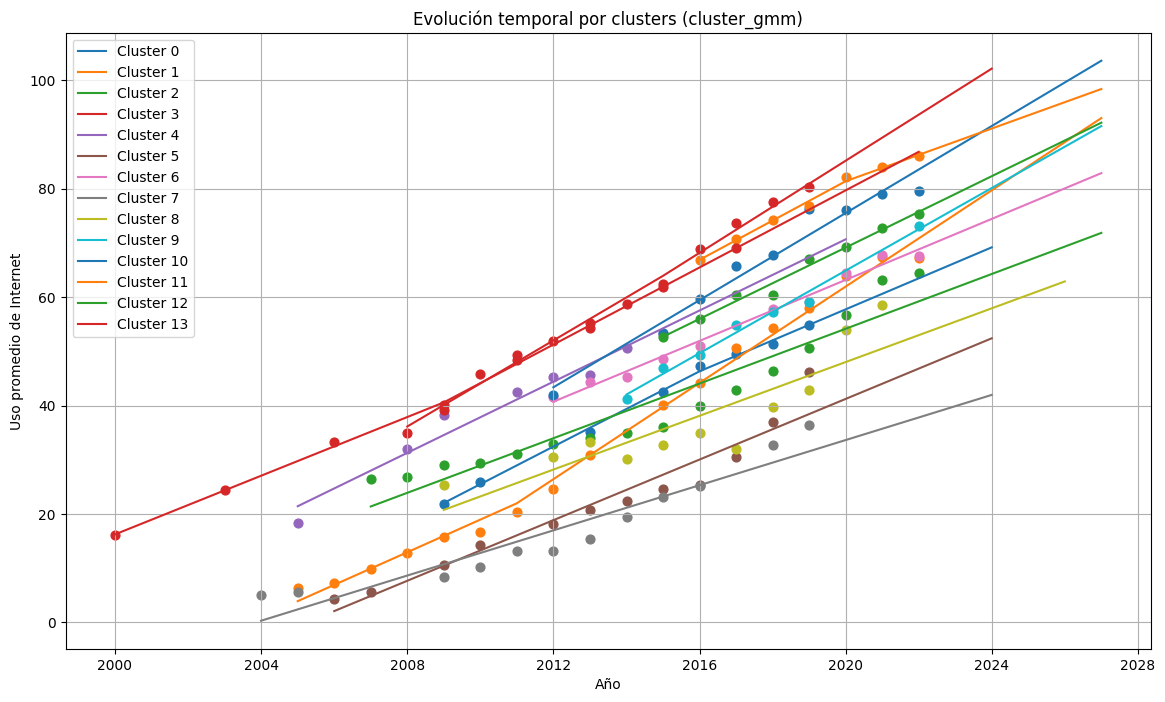

In [129]:
prophet_por_clusters(df, "cluster_gmm")

## CLUSTERING CON K-MEANS

In [130]:
# Escalar datos
kmeans_scaler = StandardScaler()

X_escalado_kmeans = kmeans_scaler.fit_transform(X_GENERAL)

# Crear modelo KMeans
kmeans = KMeans(
    n_clusters=14,
    random_state=42,
    n_init='auto'
)

# Entrenar modelo y obtener clusters
clusters_kmeans = kmeans.fit_predict(X_escalado_kmeans)

# Guardar clusters
df["cluster_kmeans"] = clusters_kmeans

### EVALUACIÓN DE K-MEANS

In [131]:
score = silhouette_score(
    X_escalado_kmeans,
    clusters_kmeans
)

print("Silhouette Score KMeans:", score)

Silhouette Score KMeans: 0.6377766716735552


### BÚSQUEDA DEL MEJOR K PARA K-MEANS

In [132]:
scores = []

for k in range(3, 25):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init='auto'
    )

    labels = model.fit_predict(X_escalado_kmeans)

    score = silhouette_score(
        X_escalado_kmeans,
        labels
    )

    scores.append((k, score))

print(scores)

[(3, 0.1540274553836139), (4, 0.1686408007298303), (5, 0.2165007349920683), (6, 0.26411867588354715), (7, 0.30938038170577337), (8, 0.3599352663588461), (9, 0.4127941611969969), (10, 0.4543067663151309), (11, 0.5016487571115419), (12, 0.5467416083086752), (13, 0.5902161380059119), (14, 0.6377766716735552), (15, 0.6054264524460176), (16, 0.5955911598931866), (17, 0.5849936377955801), (18, 0.5701320193322389), (19, 0.5570321810413199), (20, 0.5534452869955836), (21, 0.5253260047369349), (22, 0.5139169480408442), (23, 0.5008264046345514), (24, 0.4884886102022392)]


### GRÁFICA SILHOUETTE VS K (KMEANS)

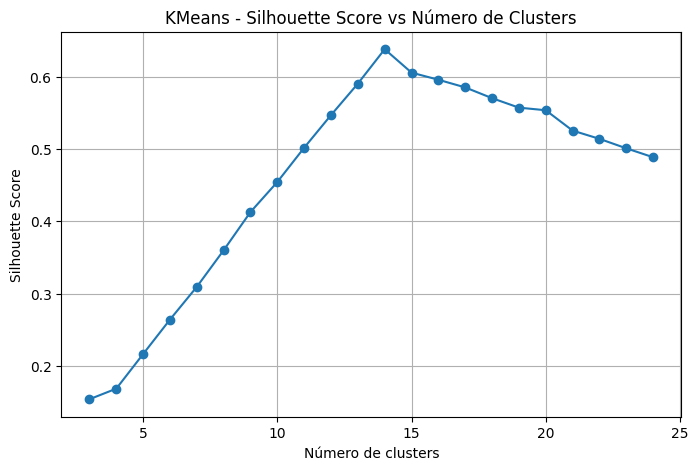

In [133]:
ks = [x[0] for x in scores]
vals = [x[1] for x in scores]

plt.figure(figsize=(8,5))

plt.plot(ks, vals, marker='o')

plt.title("KMeans - Silhouette Score vs Número de Clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")

plt.grid(True)
plt.show()

### VISUALIZACIÓN PCA DE KMEANS

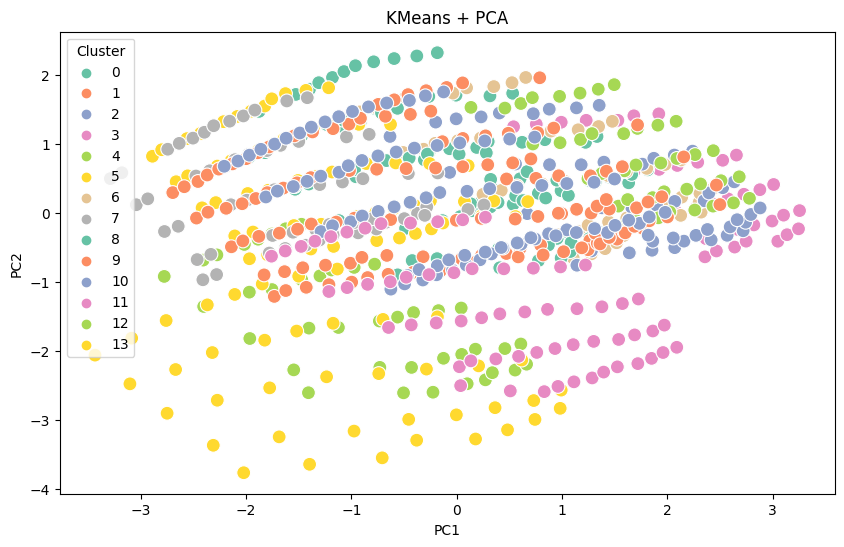

In [134]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_escalado_kmeans)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_kmeans,
    palette='Set2',
    s=100
)

plt.title("KMeans + PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend(title="Cluster")
plt.show()

### PREDICCIÓN TEMPORAL POR CLUSTERS KMEANS

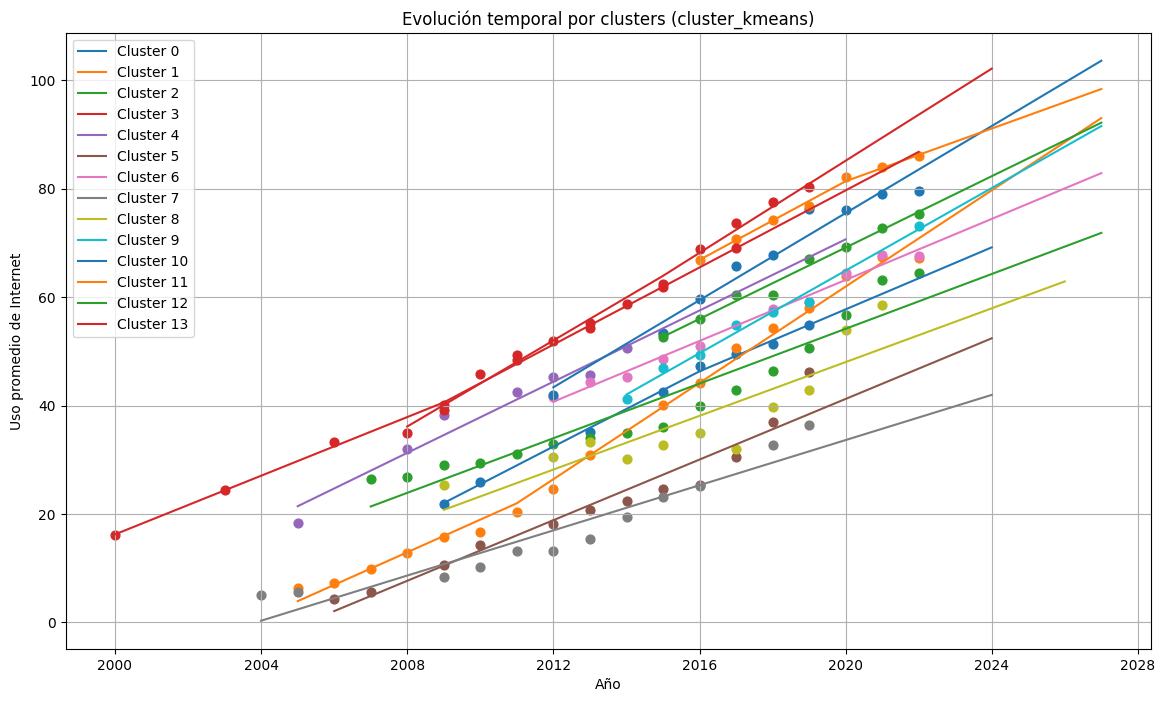

In [135]:
prophet_por_clusters(df, "cluster_kmeans")

## CLUSTERING CON OPTICS
Nota: OPTICS no usa k.
Detecta automáticamente grupos según densidad.

In [136]:
# Escalar datos
optics_scaler = StandardScaler()

X_escalado_optics = optics_scaler.fit_transform(X_GENERAL)

# Crear modelo OPTICS
optics = OPTICS(
    min_samples=10,
    # Distancia máxima entre puntos
    xi=0.05,
    # Distancia mínima para considerar separación
    min_cluster_size=0.05
)

# Entrenar modelo
clusters_optics = optics.fit_predict(X_escalado_optics)
df["cluster_optics"] = clusters_optics

### EVALUACIÓN DE OPTICS

In [137]:
# Contar clusters válidos
n_clusters = len(set(clusters_optics))

print("Clusters encontrados:", n_clusters)

# Evaluar solo si existen varios clusters
if n_clusters > 1:

    score = silhouette_score(
        X_escalado_optics,
        clusters_optics
    )

    print("Silhouette Score OPTICS:", score)

else:
    print("No se puede calcular silhouette score.")

Clusters encontrados: 13
Silhouette Score OPTICS: 0.5354983094052903


### VISUALIZACIÓN PCA DE OPTICS

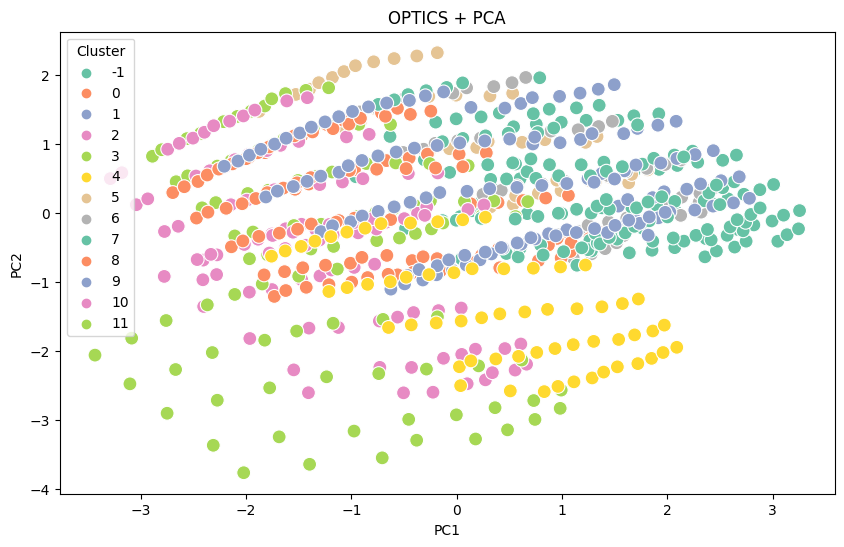

In [138]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_escalado_optics)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_optics,
    palette='Set2',
    s=100
)

plt.title("OPTICS + PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.legend(title="Cluster")
plt.show()

### PREDICCIÓN TEMPORAL POR CLUSTERS OPTICS

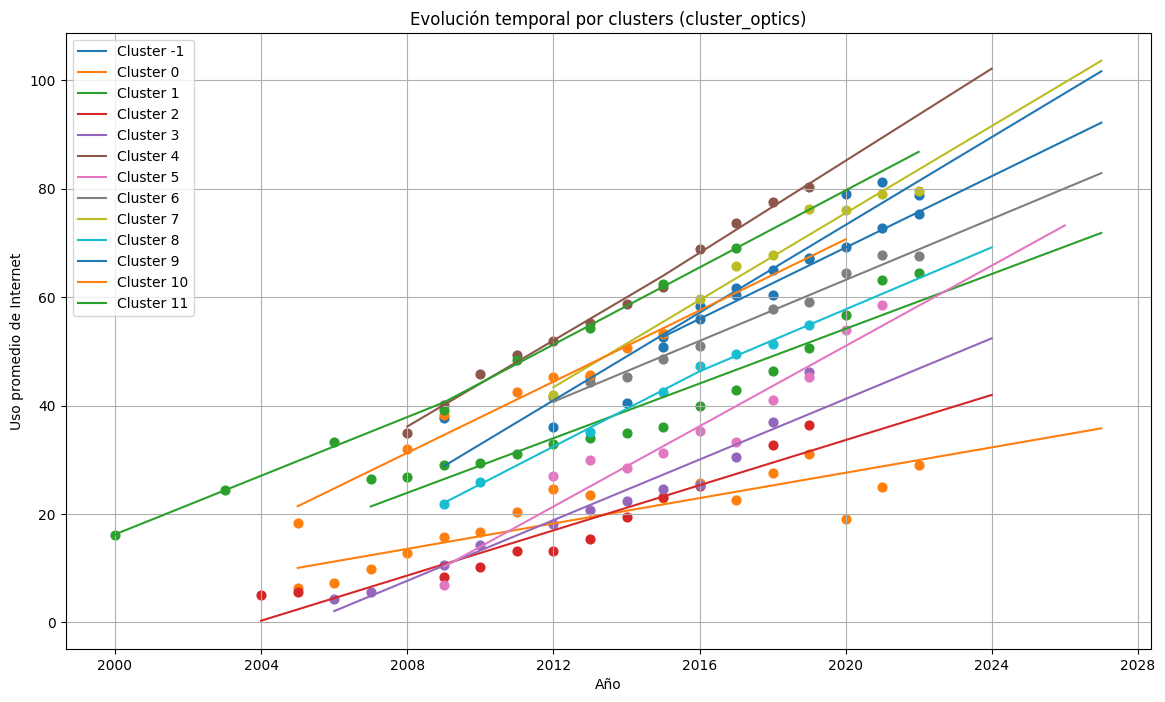

In [139]:
prophet_por_clusters(df, "cluster_optics")

## CLUSTERING JERÁRQUICO (AGGLOMERATIVE)

In [140]:
#####AGGLOMERATIVE CLUSTERING
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram


agglomerative_scaler = StandardScaler()
X_escalado_agglo = agglomerative_scaler.fit_transform(X_GENERAL)

agg = AgglomerativeClustering(
    n_clusters=14,       #nuevamente, quedó 14
    linkage='ward'           ##PROBAR CON OTROS PARÁMETROS EN SEMANA 4
)

clusters_agglo = agg.fit_predict(X_escalado_agglo)
df["cluster_agg"] = clusters_agglo

### Evaluación del clustering jerárquico

In [141]:
score = silhouette_score(X_escalado_agglo, clusters_agglo)
print("Silhouette Score:", score)

Silhouette Score: 0.6377766716735552


### Búsqueda del mejor número de clusters

In [142]:

scores = []
for k in range(3, 25):
    agg = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'          ##PROBAR CON OTROS PARÁMETROS EN SEMANA 4
    )
    labels = agg.fit_predict(X_escalado_agglo)
    score = silhouette_score(X_escalado_agglo, labels)
    scores.append((k, score))
print(scores)           #el mejor es 14, nuevamente


[(3, 0.1320358404175487), (4, 0.17241355395792488), (5, 0.20663509916562267), (6, 0.2575308653218743), (7, 0.31031055771475125), (8, 0.3670751619672385), (9, 0.41607719774629437), (10, 0.46434467248442357), (11, 0.5078666240195744), (12, 0.5519653252491783), (13, 0.5941447944982989), (14, 0.6377766716735552), (15, 0.6092101533499794), (16, 0.5888639090213453), (17, 0.5768052902154447), (18, 0.5657418772301492), (19, 0.5518940056929282), (20, 0.5382499841377952), (21, 0.5332312222780748), (22, 0.5232498558967089), (23, 0.5101323639966537), (24, 0.49912520275646516)]


### GRÁFICA DE SILHOUETTE SCORE


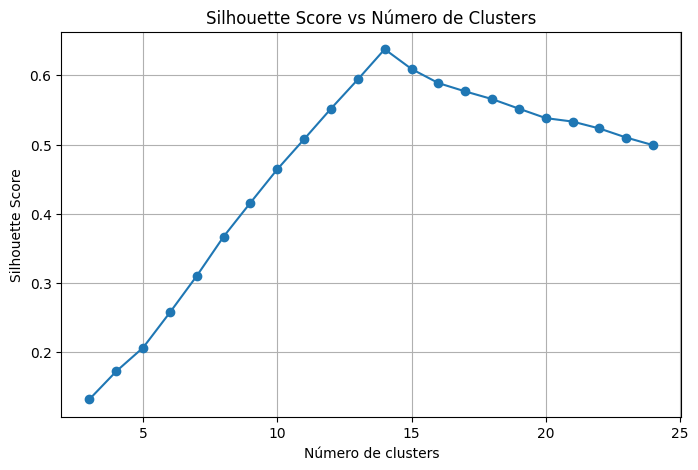

In [143]:

##graficar silhouette vs k
ks = [x[0] for x in scores]
vals = [x[1] for x in scores]
plt.figure(figsize=(8,5))
plt.plot(ks, vals, marker='o')
plt.title("Silhouette Score vs Número de Clusters")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

### Visualización PCA para Agglomerative

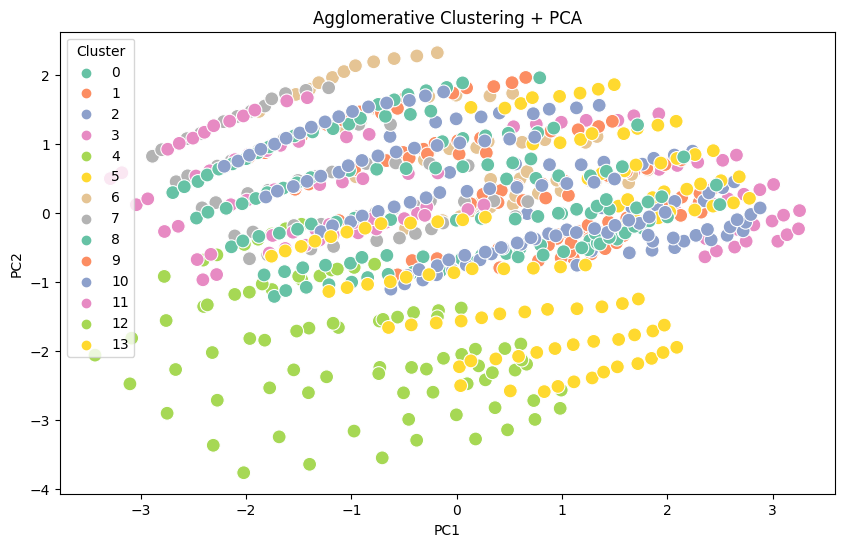

In [144]:

#### scatter de los clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado_agglo)
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters_agglo,
    palette='Set2',
    s=100
)
plt.title("Agglomerative Clustering + PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()


### DENDROGRAMA DEL CLUSTERING JERÁRQUICO

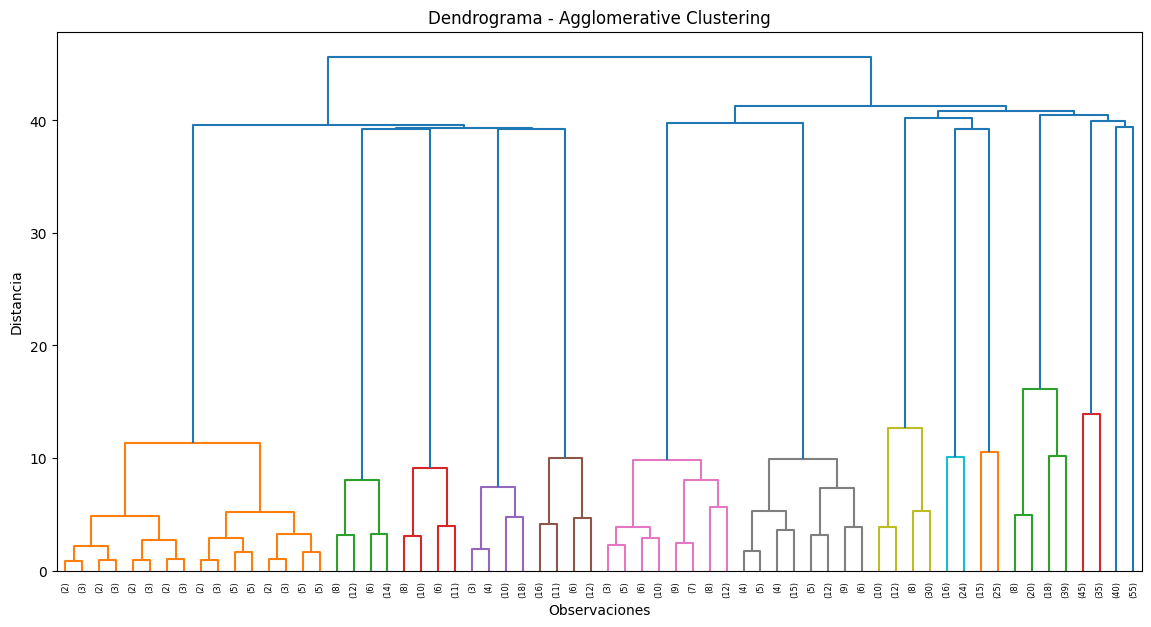

In [145]:

#### dendograma
linked = linkage(X_escalado_agglo, method='ward')
plt.figure(figsize=(14,7))
dendrogram(
    linked,
    truncate_mode='level',
    p=5
)
plt.title("Dendrograma - Agglomerative Clustering")
plt.xlabel("Observaciones")
plt.ylabel("Distancia")
plt.show()




### Predicción temporal para clusters jerárquicos

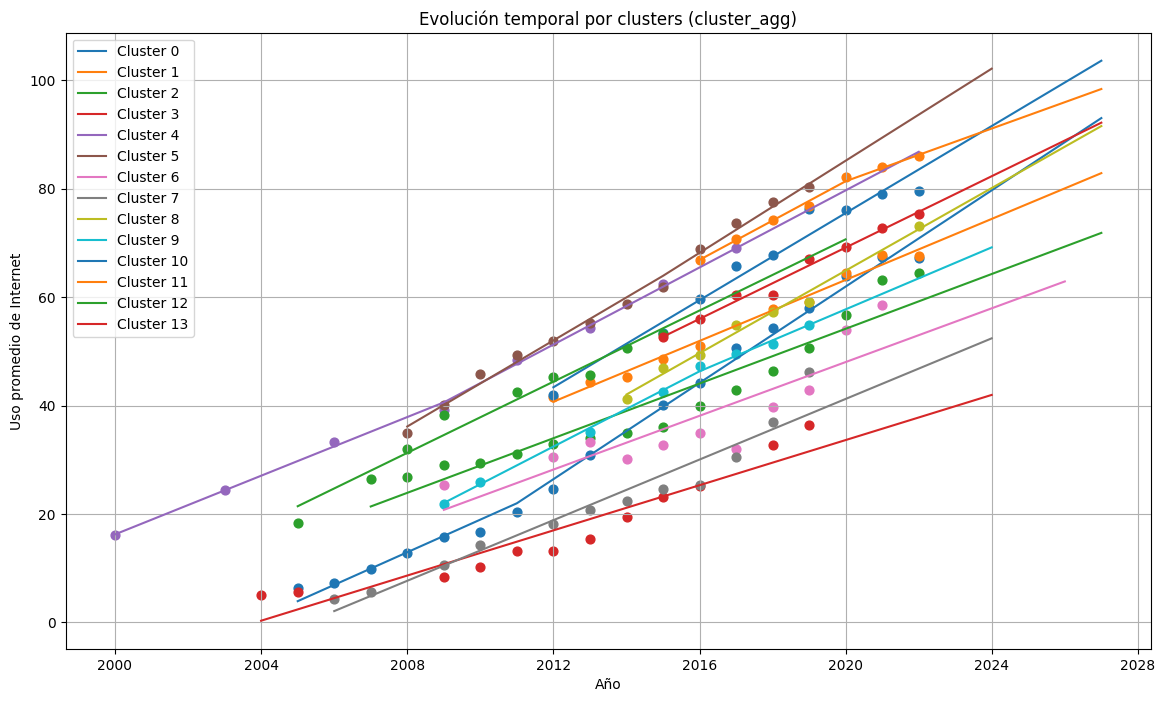

In [146]:
prophet_por_clusters(df, "cluster_agg")

## ANÁLISIS DESCRIPTIVO DE CLUSTERS


In [147]:
# Promedios por cluster GMM
print("DATOS GAUSS")
print(df.groupby("cluster_gmm")["value"].mean())
print(df.groupby("cluster_gmm")["grupo_etario_ord"].mean())
print(df.groupby("cluster_gmm")["Años__ESTANDAR"].mean())



DATOS GAUSS
cluster_gmm
0     41.100000
1     34.729412
2     40.300000
3     58.216667
4     40.725000
5     21.666667
6     54.760000
7     17.333333
8     37.672727
9     54.571429
10    66.600000
11    77.257143
12    64.225000
13    43.400000
Name: value, dtype: float64
cluster_gmm
0     2.0
1     2.0
2     2.0
3     2.0
4     2.0
5     2.0
6     2.0
7     2.0
8     2.0
9     2.0
10    2.0
11    2.0
12    2.0
13    2.0
Name: grupo_etario_ord, dtype: float64
cluster_gmm
0     2014.625000
1     2013.470588
2     2014.500000
3     2013.500000
4     2010.875000
5     2013.000000
6     2017.000000
7     2012.166667
8     2015.818182
9     2017.285714
10    2017.777778
11    2019.000000
12    2018.500000
13    2009.250000
Name: Años__ESTANDAR, dtype: float64


In [148]:
# ESTADÍSTICAS DESCRIPTIVAS KMEANS

print("DATOS KMEANS")

print(df.groupby("cluster_kmeans")["value"].mean())
print(df.groupby("cluster_kmeans")["grupo_etario_ord"].mean())


DATOS KMEANS
cluster_kmeans
0     41.100000
1     34.729412
2     40.300000
3     58.216667
4     40.725000
5     21.666667
6     54.760000
7     17.333333
8     37.672727
9     54.571429
10    66.600000
11    77.257143
12    64.225000
13    43.400000
Name: value, dtype: float64
cluster_kmeans
0     2.0
1     2.0
2     2.0
3     2.0
4     2.0
5     2.0
6     2.0
7     2.0
8     2.0
9     2.0
10    2.0
11    2.0
12    2.0
13    2.0
Name: grupo_etario_ord, dtype: float64


In [149]:
# ESTADÍSTICAS DESCRIPTIVAS OPTICS

print("DATOS OPTICS")

print(df.groupby("cluster_optics")["value"].mean())
print(df.groupby("cluster_optics")["grupo_etario_ord"].mean())

DATOS OPTICS
cluster_optics
-1     64.119266
 0     17.677966
 1     40.300000
 2     17.333333
 3     21.666667
 4     58.216667
 5     38.238095
 6     54.760000
 7     66.600000
 8     41.100000
 9     64.225000
 10    40.725000
 11    43.400000
Name: value, dtype: float64
cluster_optics
-1     1.660550
 0     2.305085
 1     2.000000
 2     2.000000
 3     2.000000
 4     2.000000
 5     2.452381
 6     2.000000
 7     2.000000
 8     2.000000
 9     2.000000
 10    2.000000
 11    2.000000
Name: grupo_etario_ord, dtype: float64


In [150]:
# Promedios por cluster Agglomerative
print("\n DATOS AGGLO")
print(df.groupby("cluster_agg")["value"].mean())
print(df.groupby("cluster_agg")["grupo_etario_ord"].mean())
print(df.groupby("cluster_agg")["Años__ESTANDAR"].mean())


 DATOS AGGLO
cluster_agg
0     34.729412
1     54.760000
2     40.300000
3     17.333333
4     43.400000
5     58.216667
6     37.672727
7     21.666667
8     54.571429
9     41.100000
10    66.600000
11    77.257143
12    40.725000
13    64.225000
Name: value, dtype: float64
cluster_agg
0     2.0
1     2.0
2     2.0
3     2.0
4     2.0
5     2.0
6     2.0
7     2.0
8     2.0
9     2.0
10    2.0
11    2.0
12    2.0
13    2.0
Name: grupo_etario_ord, dtype: float64
cluster_agg
0     2013.470588
1     2017.000000
2     2014.500000
3     2012.166667
4     2009.250000
5     2013.500000
6     2015.818182
7     2013.000000
8     2017.285714
9     2014.625000
10    2017.777778
11    2019.000000
12    2010.875000
13    2018.500000
Name: Años__ESTANDAR, dtype: float64


### MODELO PROPHET GLOBAL

In [151]:


# Renombrar columnas
df = df.rename(columns={
    "Años__ESTANDAR": "ds",
    "value": "y"
})

# Fecha
df["ds"] = pd.to_datetime(df["ds"], format="%Y")

# Crear modelo
model = Prophet()

# Regresor extra
model.add_regressor("grupo_etario_ord")

# Entrenar
model.fit(df[["ds", "y", "grupo_etario_ord"]])

# Futuro
future = model.make_future_dataframe(periods=5, freq='Y')

# Necesitas también valores del regresor
future["grupo_etario_ord"] = 0

# Predicción
forecast = model.predict(future)

print(forecast[["ds", "yhat"]].tail())




           ds        yhat
21 2022-12-31   98.112451
22 2023-12-31  102.011332
23 2024-12-31  105.466404
24 2025-12-31  109.327985
25 2026-12-31  113.208282


c:\Users\Usuario Preinstalado\AppData\Local\Programs\Python\Python311\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


# VISUALIZACIÓN DEL MODELO PROPHET

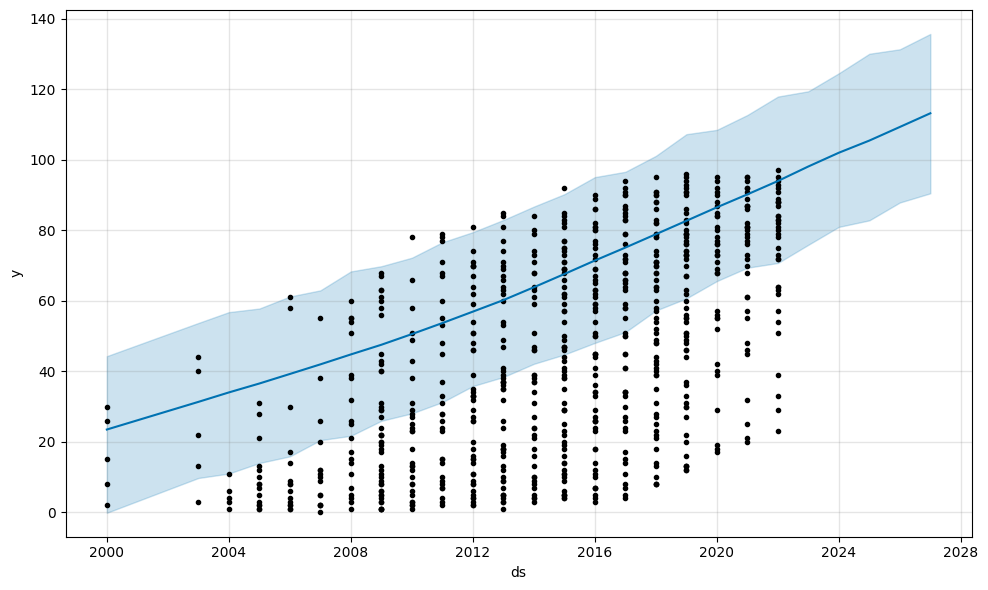

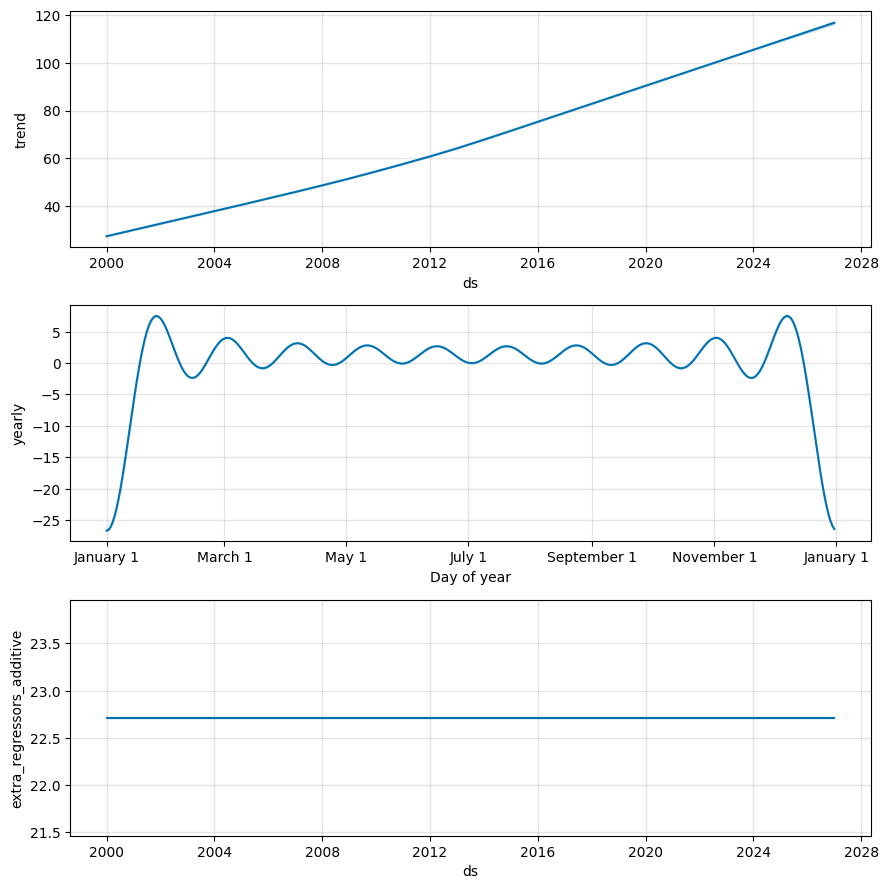

In [152]:
# Gráfica principal
fig1 = model.plot(forecast)
# Componentes del modelo
fig2 = model.plot_components(forecast)